# contact-CLASP · clasp_l1 — ESM-2 attention recovers contacts

**Question (project #7):** does a sequence-only pLM's *attention* already concentrate on residues that touch in 3D, the way coevolution does?

We take a short real chain (BPTI, `2ptc:I`), compute its true Cα contact map, and compare it to the symmetrised, APC-corrected mean of ESM-2's attention heads (the unsupervised Rao 2021 signal). Metric: **precision@L** — of the top-L predicted pairs, how many are real contacts?

> The 8M model here is for speed; contact signal is far stronger in ESM-2 650M (the scale-up). See [`common/`](../common) for the shared primitives.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "clasp"))   # for `import clasp_common`
DATA = os.path.join(ROOT, "data")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from clasp_common import load_demo_chain, esm_attention_contacts, precision_at_l
seq, coords, true = load_demo_chain(cache_dir=DATA)
print(f'{len(seq)} residues; {int(true[true].sum())//1} contact cells')
attn = esm_attention_contacts(seq)
print('precision@L (attention):', round(precision_at_l(attn, true), 3))

58 residues; 246 contact cells


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


precision@L (attention): 0.069


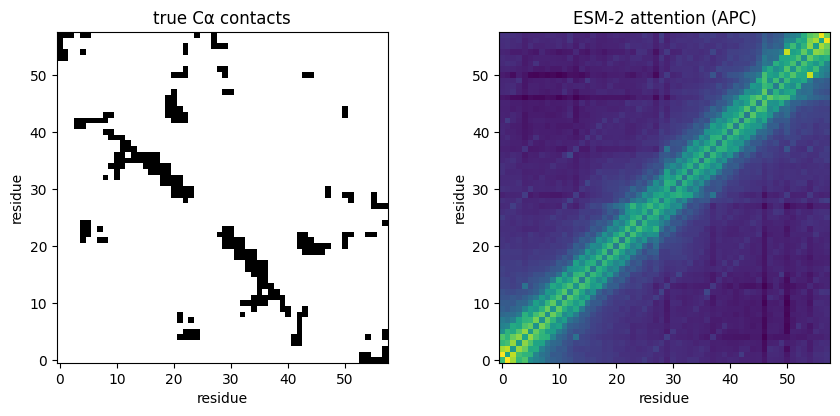

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].imshow(true, cmap="Greys", origin="lower"); ax[0].set_title("true Cα contacts")
im = ax[1].imshow(attn, cmap="viridis", origin="lower"); ax[1].set_title("ESM-2 attention (APC)")
for a in ax: a.set_xlabel("residue"); a.set_ylabel("residue")
plt.tight_layout(); plt.show()

### Things to experiment with
- Swap `facebook/esm2_t6_8M_UR50D` → `...t33_650M...` and watch precision@L jump.
- Replace the head *average* with a logistic regression over heads (Rao 2021, supervised).
- Try other chains from `common`'s demo complexes.